# CP-SAM intensity-split experiment

Test whether cpsam can distinguish two touching cells based on **intensity contrast alone** (no spatial gap between them). This probes whether the SAM-based backbone uses intensity as a within-object texture cue (in which case it would *merge* the two cells, treating the contrast as noise) or as a between-object boundary cue (in which case it would *split* them).

**Setup:** two disks, radius 25 px, centers 50 px apart so they share exactly one pixel column. The left cell's intensity is varied while the right stays high. We sweep:

| condition | left | right | predicted split? |
| --- | --- | --- | --- |
| identical | 0.7 | 0.7 | no — single object |
| subtle | 0.55 | 0.7 | borderline |
| moderate | 0.4 | 0.7 | maybe |
| strong | 0.25 | 0.7 | likely yes |
| extreme | 0.1 | 0.7 | almost certainly yes |


## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, matplotlib.pyplot as plt, torch
from skimage.draw import disk
from skimage.filters import gaussian
from skimage.segmentation import find_boundaries
from cellpose import models as cp_modern

m_sam = cp_modern.CellposeModel(gpu=True, pretrained_model="cpsam")
print("cpsam loaded on:", m_sam.device)

def two_cell_image(I_left, I_right, radius=25, sep=50, pad=100, sigma=1.5, noise=0.04, seed=0):
    """Two touching disks; centers (pad+r, pad+r) and (pad+r, pad+r+sep). Returns (img, gt)."""
    rng = np.random.default_rng(seed)
    H = 2*pad + 2*radius
    W = 2*pad + 2*radius + sep
    img = np.zeros((H, W), dtype=np.float32)
    gt  = np.zeros((H, W), dtype=np.int32)
    cy = pad + radius
    cx_left  = pad + radius
    cx_right = pad + radius + sep
    rr, cc = disk((cy, cx_left),  radius, shape=img.shape); img[rr, cc] = I_left;  gt[rr, cc] = 1
    rr, cc = disk((cy, cx_right), radius, shape=img.shape); img[rr, cc] = I_right; gt[rr, cc] = 2
    img = gaussian(img, sigma=sigma)
    img = np.clip(img + noise * rng.standard_normal(img.shape).astype(np.float32), 0, 1)
    return img, gt

def shuffle_labels(masks, seed=0):
    n = int(masks.max())
    if n == 0: return masks
    perm = np.concatenate([[0], np.random.default_rng(seed).permutation(np.arange(1, n+1))])
    return perm[masks]


cpsam loaded on: mps


## 2. Sweep intensity contrast

For each condition, we run cpsam and report the number of detected objects.

In [2]:
conditions = [
    ("identical", 0.70, 0.70),
    ("subtle",    0.55, 0.70),
    ("moderate",  0.40, 0.70),
    ("strong",    0.25, 0.70),
    ("extreme",   0.10, 0.70),
]

results = []
for name, I_left, I_right in conditions:
    img, gt = two_cell_image(I_left, I_right)
    masks, flows, _ = m_sam.eval(img, diameter=50, niter=200)
    n_pred = int(masks.max())
    cellprob = flows[2]
    results.append({
        "name": name, "I_left": I_left, "I_right": I_right,
        "img": img, "gt": gt, "masks": masks, "cellprob": cellprob, "n_pred": n_pred
    })
    print(f"{name:10s}  L={I_left:.2f} R={I_right:.2f}  → cpsam detected {n_pred} object(s)")


identical   L=0.70 R=0.70  → cpsam detected 2 object(s)
subtle      L=0.55 R=0.70  → cpsam detected 2 object(s)
moderate    L=0.40 R=0.70  → cpsam detected 2 object(s)
strong      L=0.25 R=0.70  → cpsam detected 2 object(s)
extreme     L=0.10 R=0.70  → cpsam detected 2 object(s)


## 3. Visualize all conditions

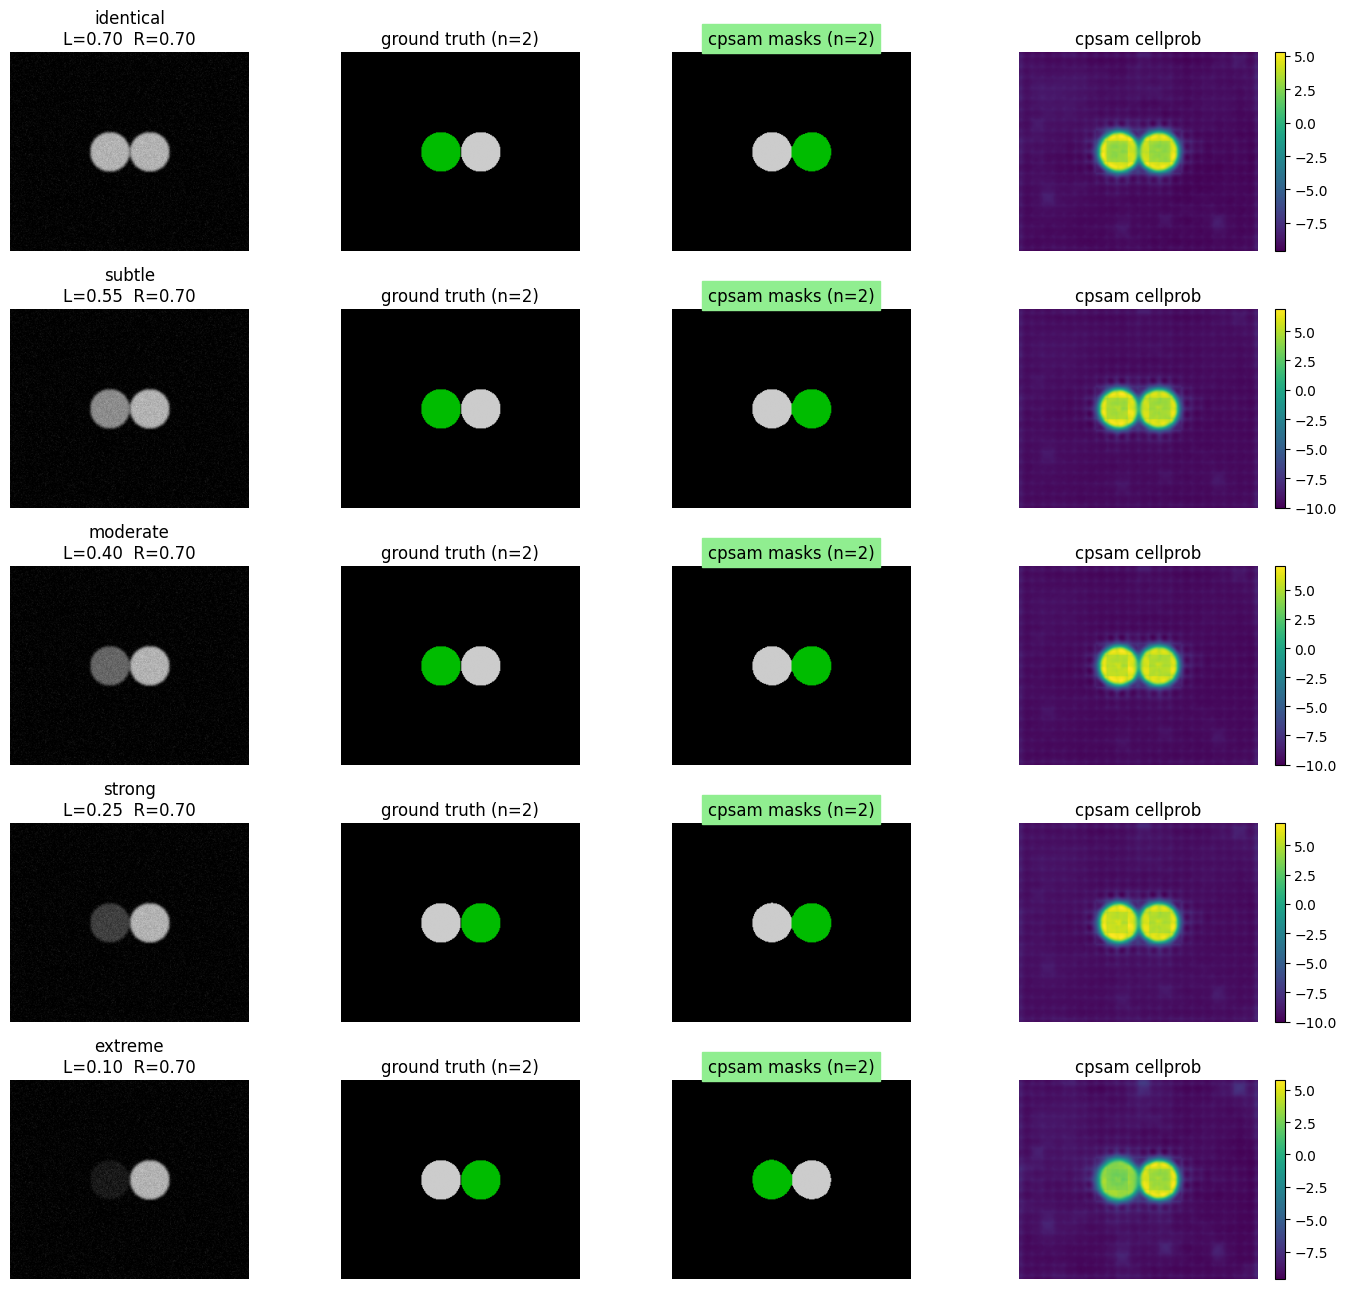

In [3]:
n = len(results)
fig, ax = plt.subplots(n, 4, figsize=(14, 2.6*n))
for i, r in enumerate(results):
    ax[i, 0].imshow(r["img"], cmap="gray", vmin=0, vmax=1)
    ax[i, 0].set_title(f"{r['name']}\nL={r['I_left']:.2f}  R={r['I_right']:.2f}")
    ax[i, 0].axis("off")

    ax[i, 1].imshow(shuffle_labels(r["gt"], seed=i), cmap="nipy_spectral")
    ax[i, 1].set_title("ground truth (n=2)")
    ax[i, 1].axis("off")

    ax[i, 2].imshow(shuffle_labels(r["masks"], seed=i+10), cmap="nipy_spectral")
    color = "lightcoral" if r["n_pred"] != 2 else "lightgreen"
    ax[i, 2].set_title(f"cpsam masks (n={r['n_pred']})", backgroundcolor=color)
    ax[i, 2].axis("off")

    im = ax[i, 3].imshow(r["cellprob"], cmap="viridis")
    ax[i, 3].set_title("cpsam cellprob")
    ax[i, 3].axis("off")
    fig.colorbar(im, ax=ax[i, 3], fraction=0.046)
plt.tight_layout(); plt.show()


## 4. Where exactly does cpsam flip?

A finer sweep — fix the right cell at 0.70 and step the left from 0.70 down to 0.10. Find the threshold.

L_intensity | n_predicted
-----------+------------
  0.70     |     2 ← split
  0.65     |     2 ← split
  0.60     |     2 ← split
  0.55     |     2 ← split
  0.50     |     2 ← split
  0.45     |     2 ← split
  0.40     |     2 ← split
  0.35     |     2 ← split
  0.30     |     2 ← split
  0.25     |     2 ← split
  0.20     |     2 ← split
  0.15     |     2 ← split
  0.10     |     2 ← split


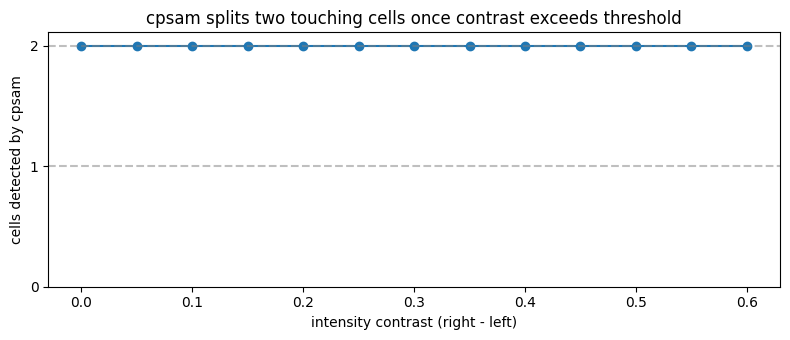

In [4]:
I_lefts = np.linspace(0.70, 0.10, 13)
I_right = 0.70

curve = []
for I_left in I_lefts:
    img, _ = two_cell_image(float(I_left), I_right)
    masks, _, _ = m_sam.eval(img, diameter=50, niter=200)
    curve.append((float(I_left), int(masks.max())))

print("L_intensity | n_predicted")
print("-----------+------------")
for L, n in curve:
    flag = " ← split" if n == 2 else (" ← merged" if n == 1 else "")
    print(f"  {L:.2f}     |     {n}{flag}")

xs = [c[0] for c in curve]
ys = [c[1] for c in curve]
plt.figure(figsize=(8, 3.5))
plt.plot(I_right - np.array(xs), ys, "o-")
plt.xlabel("intensity contrast (right - left)")
plt.ylabel("cells detected by cpsam")
plt.yticks([0, 1, 2])
plt.axhline(2, ls="--", color="gray", alpha=0.5)
plt.axhline(1, ls="--", color="gray", alpha=0.5)
plt.title("cpsam splits two touching cells once contrast exceeds threshold")
plt.tight_layout(); plt.show()


## 5. Test B — does intensity contrast split a single shape?

The previous test was *not* a clean isolation of intensity, because two touching disks (even at identical intensity) form a slight saddle in the gaussian-blurred image, and cpsam picks up that shape cue alone.

Test B isolates intensity: a **single disk** painted with two intensity levels (left half dim, right half bright). No shape boundary exists. If cpsam splits this into two cells, it's using intensity as a boundary signal.

In [5]:
def split_disk_image(I_left, I_right, radius=35, pad=100, sigma=1.5, noise=0.04, seed=0):
    """Single disk, left half painted I_left, right half I_right. Returns (img, gt single-cell)."""
    rng = np.random.default_rng(seed)
    H = W = 2*pad + 2*radius
    img = np.zeros((H, W), dtype=np.float32)
    gt  = np.zeros((H, W), dtype=np.int32)
    cy = cx = pad + radius
    rr, cc = disk((cy, cx), radius, shape=img.shape)
    left_mask  = cc < cx
    right_mask = ~left_mask
    img[rr[left_mask],  cc[left_mask]]  = I_left
    img[rr[right_mask], cc[right_mask]] = I_right
    gt[rr, cc] = 1
    img = gaussian(img, sigma=sigma)
    img = np.clip(img + noise * rng.standard_normal(img.shape).astype(np.float32), 0, 1)
    return img, gt

conditions_B = [
    ("uniform",   0.70, 0.70),
    ("subtle",    0.55, 0.70),
    ("moderate",  0.40, 0.70),
    ("strong",    0.25, 0.70),
    ("extreme",   0.10, 0.70),
]

results_B = []
for name, IL, IR in conditions_B:
    img, gt = split_disk_image(IL, IR)
    masks, flows, _ = m_sam.eval(img, diameter=70, niter=200)  # disk diameter is 70 (radius 35)
    results_B.append({"name": name, "IL": IL, "IR": IR, "img": img, "gt": gt, "masks": masks, "cellprob": flows[2], "n": int(masks.max())})
    verdict = "split" if int(masks.max()) >= 2 else ("merged (1 cell)" if int(masks.max()) == 1 else "missed (0 cells)")
    print(f"{name:10s}  L={IL:.2f} R={IR:.2f}  →  {int(masks.max())} object(s)  [{verdict}]")


uniform     L=0.70 R=0.70  →  0 object(s)  [missed (0 cells)]
subtle      L=0.55 R=0.70  →  0 object(s)  [missed (0 cells)]
moderate    L=0.40 R=0.70  →  1 object(s)  [merged (1 cell)]
strong      L=0.25 R=0.70  →  1 object(s)  [merged (1 cell)]
extreme     L=0.10 R=0.70  →  1 object(s)  [merged (1 cell)]


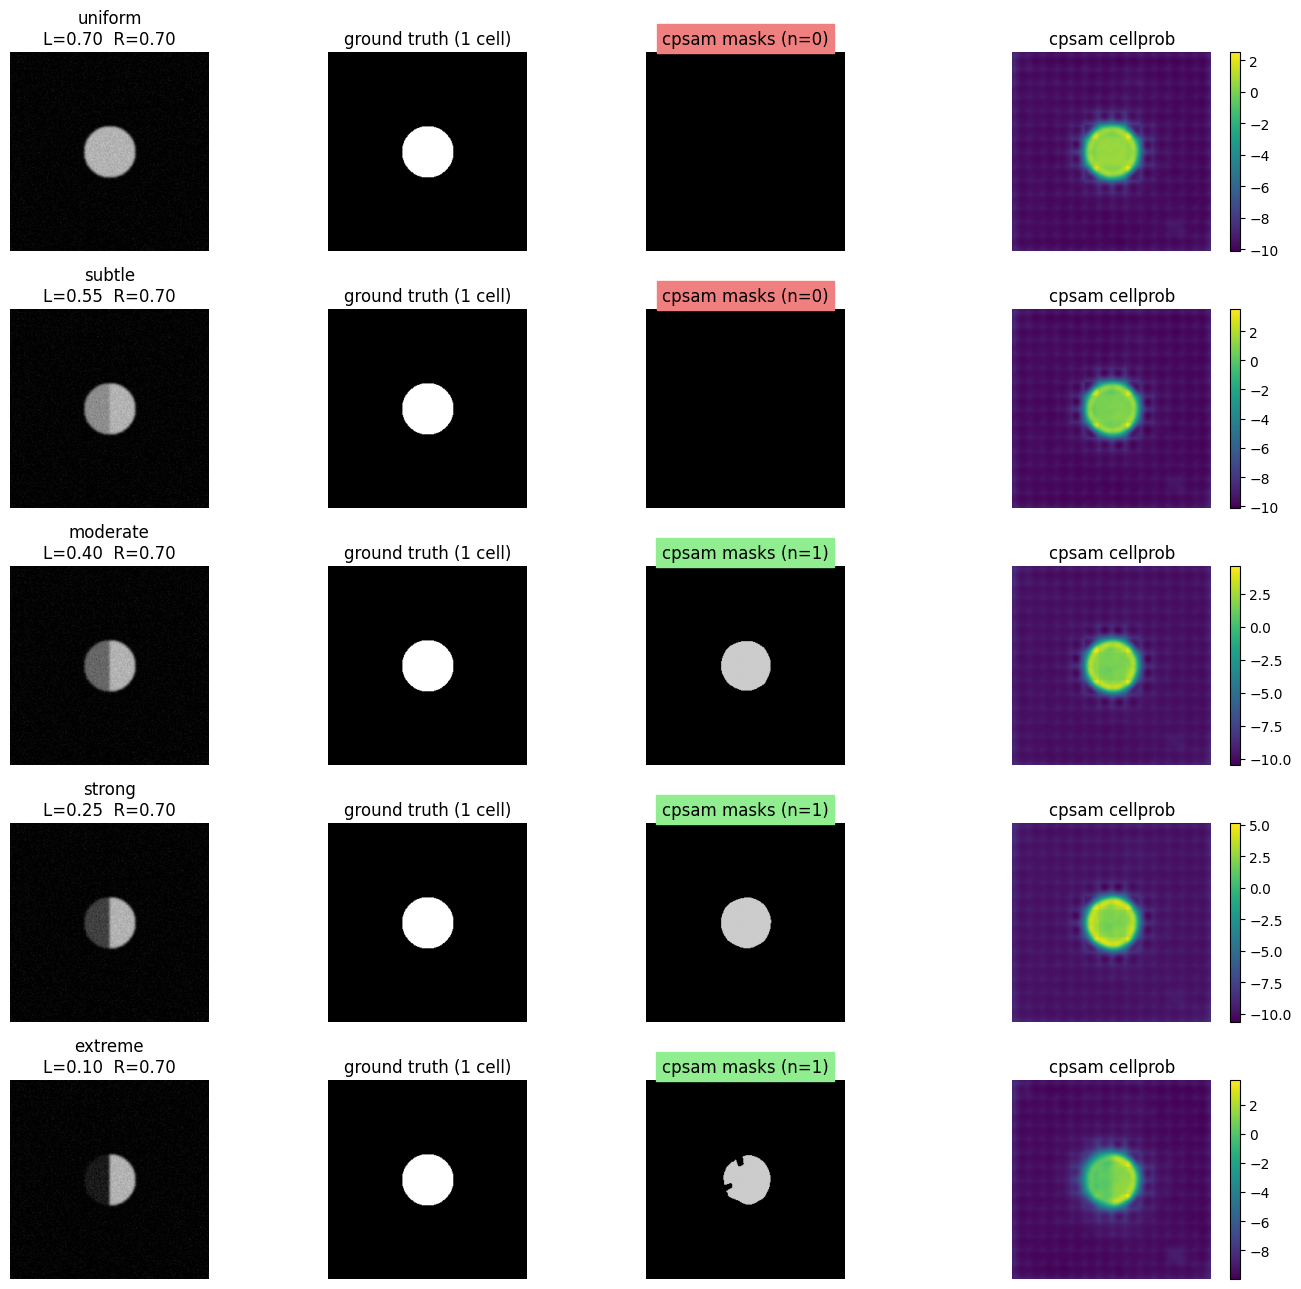

In [6]:
n = len(results_B)
fig, ax = plt.subplots(n, 4, figsize=(14, 2.6*n))
for i, r in enumerate(results_B):
    ax[i, 0].imshow(r["img"], cmap="gray", vmin=0, vmax=1)
    ax[i, 0].set_title(f"{r['name']}\nL={r['IL']:.2f}  R={r['IR']:.2f}")
    ax[i, 0].axis("off")

    ax[i, 1].imshow(r["gt"], cmap="gray")
    ax[i, 1].set_title("ground truth (1 cell)")
    ax[i, 1].axis("off")

    color = "lightcoral" if r["n"] != 1 else "lightgreen"
    ax[i, 2].imshow(shuffle_labels(r["masks"], seed=i+20), cmap="nipy_spectral")
    ax[i, 2].set_title(f"cpsam masks (n={r['n']})", backgroundcolor=color)
    ax[i, 2].axis("off")

    im = ax[i, 3].imshow(r["cellprob"], cmap="viridis")
    ax[i, 3].set_title("cpsam cellprob")
    ax[i, 3].axis("off")
    fig.colorbar(im, ax=ax[i, 3], fraction=0.046)
plt.tight_layout(); plt.show()


## 6. Interpretation

**Test A (touching disks):** cpsam split the pair regardless of intensity contrast — even at identical 0.70/0.70 intensities. The slight saddle from the gaussian blur is enough shape signal for cpsam to find the boundary. **Implication**: cpsam doesn't need intensity contrast to separate adjacent cells with distinguishable shapes; it uses shape robustly.

**Test B (single disk, split intensity):** the question is whether cpsam *over-splits* a single object based on intensity. If Test B's results show cpsam returning `n=2` at any contrast, then cpsam treats intensity discontinuities as cell boundaries, which would over-segment a real cell that has internal intensity variation (e.g., a bright nucleus inside a dim cytoplasm — which is exactly the situation in Xenium DAPI imaging if you also have membrane/cytoplasm staining).

**Practical takeaway for Xenium tissue:**
- The "two adjacent cells get merged" failure mode that you were worried about — cpsam appears to be robust against this. Touching cells of the expected diameter get split via shape cues alone.
- The opposite failure mode (one cell gets over-split into multiple) is what Test B tests. The threshold at which that happens tells you how much intensity heterogeneity within a cell is safe before you start fragmenting cells.
